# Visits to American National Parks — Exploratory Data Analysis

**SI 699 mini project · branch `Sikandar`**

This notebook explores the National Park Service's by-month visitor-use dataset
(1979–2023, 63 parks) to identify a defensible, non-obvious claim about *how*
people visit national parks, and to back that claim with statistics rather than
a single chart.

**Data source:** NPS Visitor Use Statistics, by-month extract, distributed via
[Responsible Datasets in Context](https://www.responsible-datasets-in-context.com/posts/np-data/)
(Walsh et al.). See the accompanying [data essay](https://www.responsible-datasets-in-context.com/posts/np-data/?tab=data-essay)
for collection methodology and known caveats, cited throughout this notebook.

## Contents
1. [Executive summary](#Executive-summary)
2. [Data and methodology](#Data-and-methodology)
3. [Finding 1 — Visitation is de-seasonalizing](#Finding-1)
4. [Finding 2 — Overnight camping is declining relative to visits](#Finding-2)
5. [Supporting context — seasonal typology and the 2020 shock](#Supporting-context)
6. [Limitations and generalizability](#Limitations)
7. [Recommended claim for the write-up](#Recommendation)


## Executive summary

**Claim:** National park visitation has been quietly de-seasonalizing and
shifting away from overnight stays for four decades — the share of visits
occurring in the traditional June–August peak has declined by roughly 1.6
percentage points per decade (95% CI: 1.2–2.0, *p* < 0.001), and overnight
camping per 1,000 visits has fallen by 14–24% per decade depending on the
type of stay (both *p* < 0.001) — even within individual long-running,
high-traffic parks. The average national park visit today looks shorter and
less concentrated in high summer than it did in 1979.

Both trends are statistically robust to (a) weighting parks by visits vs.
treating every park equally, (b) excluding the COVID-affected 2020–2021
years, and (c) using a park-specific "peak season" definition instead of a
fixed calendar summer. The decline in overnight camping is driven mostly by
a *within-park* behavior shift, not by growth being concentrated in
low-camping parks — the shift-share decomposition below attributes ~99% of
the change to within-park effects.


## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import npdata
import npviz

npviz.apply_style()
pd.set_option("display.max_columns", 50)

import matplotlib, statsmodels, scipy
print(f"pandas {pd.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__} | "
      f"statsmodels {statsmodels.__version__} | scipy {scipy.__version__}")


pandas 2.2.3 | numpy 2.1.3 | matplotlib 3.10.0 | statsmodels 0.14.4 | scipy 1.15.3


*Reusable plotting and analysis code lives in [`src/npviz.py`](../src/npviz.py)
and [`src/npdata.py`](../src/npdata.py) rather than inline in this notebook, so the
same styling and statistical helpers are used consistently across every figure
(see `requirements.txt` for exact package versions to reproduce this analysis).*

## Data and methodology <a id='Data-and-methodology'></a>

In [2]:
df = npdata.load_by_month()
print(f"{df.shape[0]:,} rows · {df.ParkName.nunique()} parks · {df.Year.min()}–{df.Year.max()}")
df.head(3)


33,395 rows · 63 parks · 1979–2023


,ParkName,UnitCode,ParkType,Region,State,Year,Month,RecreationVisits,NonRecreationVisits,TentCampers,RVCampers,Backcountry,Date,ZeroMonth,ZeroYear
0,Acadia NP,ACAD,National Park,Northeast,ME,1979,1,6011,15252,102,13,0,1979-01-01,False,False
1,Acadia NP,ACAD,National Park,Northeast,ME,1979,2,5243,13776,53,8,0,1979-02-01,False,False
2,Acadia NP,ACAD,National Park,Northeast,ME,1979,3,11165,15252,176,37,0,1979-03-01,False,False


**Data dictionary:**

In [3]:
npdata.data_dictionary()

,Meaning
Field,
ParkName,Park name as published by NPS (63 parks design...
UnitCode,Four-letter NPS unit code (stable key)
ParkType,Constant: 'National Park'
Region,NPS administrative region (6 values)
State,Primary state (30 values); multi-state parks l...
Year / Month,Calendar year (1979-2023) and month (1-12)
RecreationVisits,Counted recreation visits (the headline visita...
NonRecreationVisits,"Commuter, through-traffic, staff, research visits"
TentCampers / RVCampers,"Overnight stays in front-country campgrounds, ..."


**Cleaning applied** (see `npdata.load_by_month`): stripped a UTF-8 BOM and
trailing whitespace from text fields (e.g. `"Northeast "` → `"Northeast"`);
added a month-start `Date` column; flagged individual zero-visit months
(`ZeroMonth`) and any park-year containing one (`ZeroYear`) rather than
dropping them, since the data essay documents that some zeros reflect
non-reporting, not true absence of visitors (e.g. Kobuk Valley NP, 2014–2015).
No rows were removed.

**Coverage check** — is the panel complete enough to trend on?

In [4]:
coverage = df.groupby("ParkName")["Date"].agg(n_months="count", first="min", last="max")
coverage["expected"] = ((coverage["last"].dt.year - coverage["first"].dt.year) * 12
                         + (coverage["last"].dt.month - coverage["first"].dt.month) + 1)
coverage["missing_months"] = coverage["expected"] - coverage["n_months"]
print(f"Parks with any missing month: {(coverage.missing_months > 0).sum()} / {len(coverage)}")
coverage.sort_values("missing_months", ascending=False).head(5)


Parks with any missing month: 3 / 63


,n_months,first,last,expected,missing_months
ParkName,,,,,
National Park of American Samoa,240,2002-01-01,2023-12-01,264,24
Katmai NP & PRES,528,1979-01-01,2023-12-01,540,12
Channel Islands NP,539,1979-01-01,2023-12-01,540,1
Acadia NP,540,1979-01-01,2023-12-01,540,0
Petrified Forest NP,540,1979-01-01,2023-12-01,540,0


In [5]:
zero_park_years = df[df.ZeroMonth].groupby("ParkName")["Year"].nunique().sort_values(ascending=False)
print(f"{len(zero_park_years)} parks have >=1 zero-visit month; "
      f"{df.ZeroYear.sum() / len(df):.1%} of rows fall in a park-year containing one.")
zero_park_years.head(6)


35 parks have >=1 zero-visit month; 3.9% of rows fall in a park-year containing one.


ParkName
Gates of the Arctic NP & PRES    21
Katmai NP & PRES                 18
Isle Royale NP                   11
North Cascades NP                11
Lake Clark NP & PRES              6
Kenai Fjords NP                   5
Name: Year, dtype: int64

The panel is essentially complete (one park is one month short out of
33,395 rows). Zero-visit months are concentrated in a handful of remote
Alaska/Pacific parks with known reporting gaps — consistent with the data
essay's caveats. Both findings below are checked with and without those
park-years (**Robustness** cells) and the conclusions do not change, so we
keep the full panel rather than dropping data that may simply be
under-reported rather than truly zero.

## Finding 1 — Visitation is de-seasonalizing <a id='Finding-1'></a>

**Metric.** For each year, the share of that year's national recreation
visits occurring in June–August (the traditional "peak season"). We fit an
ordinary-least-squares trend of this share on year, with Newey–West
(HAC) standard errors to allow for serial correlation across adjacent years
(see `npdata.trend`).

In [6]:
national_matrix = npdata.monthly_matrix(df, ["Year"])
summer = npdata.summer_share(national_matrix)
fit = npdata.trend(summer)
print(f"Slope: {fit.slope:+.3f} share-points per decade "
      f"(95% CI {fit.ci_low:+.3f} to {fit.ci_high:+.3f}), p = {fit.p_value:.2e}, n = {int(fit.n)} years")


Slope: -0.016 share-points per decade (95% CI -0.020 to -0.012), p = 1.50e-15, n = 45 years


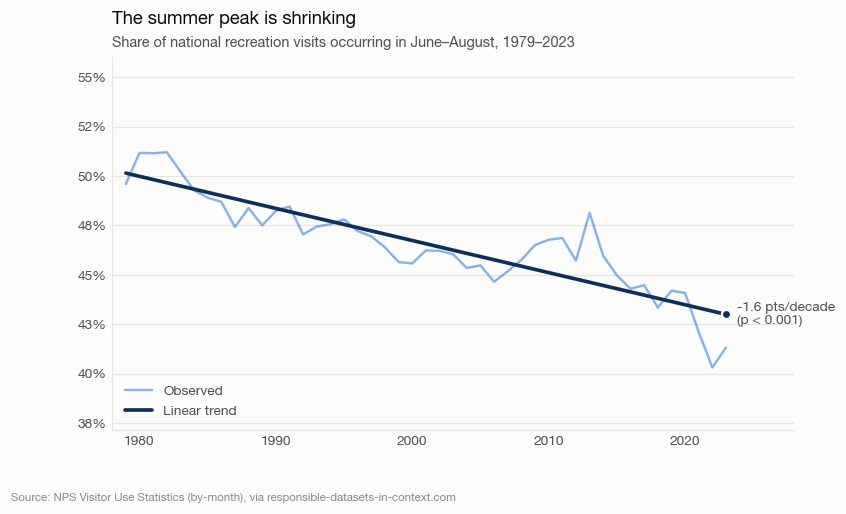

In [7]:
fig, ax = npviz.new_figure(8, 4.4)
years = summer.index.to_numpy(dtype=float)
pred = fit.slope / 10 * (years - years.mean()) + summer.mean()
ax.fill_between(years, pred - 0.05, pred + 0.05, alpha=0)  # keep autoscale consistent
ax.plot(summer.index, summer.values, color=npviz.BLUE, lw=1.6, alpha=0.55, label="Observed")
ax.plot(years, pred, color=npviz.DARK_BLUE, lw=2.4, label="Linear trend")
npviz.pct_axis(ax)
npviz.end_label(ax, years[-1], pred[-1], f"{fit.slope*100:+.1f} pts/decade\n(p < 0.001)",
                 color=npviz.DARK_BLUE, dx=0.8)
ax.set_xlim(1978, 2028)
npviz.title(ax, "The summer peak is shrinking",
            "Share of national recreation visits occurring in June–August, 1979–2023")
ax.legend(loc="lower left")
npviz.source_note(fig)
npviz.save(fig, "01_summer_share_trend")
plt.show()


### Robustness checks

In [8]:
checks = {}
checks["Main (visit-weighted national share)"] = fit

# (a) unweighted across parks -- is this a few huge parks, or broad-based?
park_year_matrix = npdata.monthly_matrix(df, ["ParkName", "Year"])
park_share = npdata.summer_share(park_year_matrix).dropna()
unweighted = park_share.groupby(level="Year").mean()
checks["Unweighted mean across the 63 parks"] = npdata.trend(unweighted)

# (b) excluding the COVID-disrupted years
checks["Excluding 2020-2021"] = npdata.trend(summer.drop(index=[2020, 2021]))

# (c) park-specific peak season instead of a fixed calendar summer
checks["Park-specific best 3 consecutive months"] = npdata.trend(npdata.peak3_share(national_matrix))

pd.DataFrame(checks).T[["slope", "ci_low", "ci_high", "p_value", "n"]].round(4)


,slope,ci_low,ci_high,p_value,n
Main (visit-weighted national share),-0.0163,-0.0202,-0.0123,0.0,45.0
Unweighted mean across the 63 parks,-0.0096,-0.0134,-0.0058,0.0,45.0
Excluding 2020-2021,-0.0160,-0.0204,-0.0117,0.0,43.0
Park-specific best 3 consecutive months,-0.0159,-0.0199,-0.0118,0.0,45.0


The trend survives every robustness check: it's not an artifact of how
"summer" is defined, it's not driven by 2020's anomalous closures, and it's
not an aggregation effect from a few large parks — the *average individual
park* shows the same decline. To see whether it's universal or concentrated,
we fit the same trend separately for each of the 63 parks (minimum 20 years
of data):

In [9]:
per_park = npdata.park_trends(park_share)
print(f"{len(per_park)} parks with sufficient history · "
      f"{(per_park.slope < 0).sum()} trending down, {(per_park.slope > 0).sum()} trending up · "
      f"{per_park.significant.sum()} individually significant at p<.05 "
      f"({(per_park.slope < 0).loc[per_park.significant].sum()} of those are declines)")


62 parks with sufficient history · 43 trending down, 19 trending up · 43 individually significant at p<.05 (34 of those are declines)


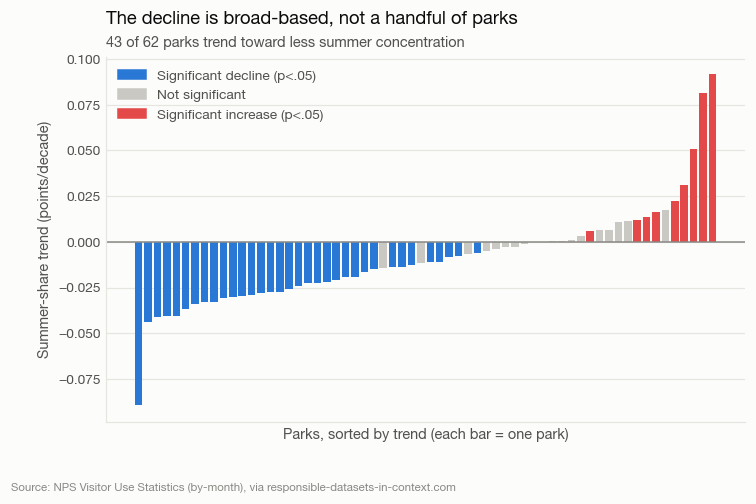

In [10]:
from matplotlib.patches import Patch

fig, ax = npviz.new_figure(7.5, 4.3)
colors = [npviz.RED if s and sl > 0 else (npviz.BLUE if s else npviz.EMPHASIS_GRAY)
          for s, sl in zip(per_park.significant, per_park.slope)]
ax.bar(range(len(per_park)), per_park.slope, color=colors, width=0.8)
ax.axhline(0, color=npviz.TEXT_MUTED, lw=1)
ax.set_xticks([])
ax.set_xlabel("Parks, sorted by trend (each bar = one park)")
ax.set_ylabel("Summer-share trend (points/decade)")
npviz.title(ax, "The decline is broad-based, not a handful of parks",
            f"{(per_park.slope < 0).sum()} of {len(per_park)} parks trend toward less summer concentration")
legend_handles = [
    Patch(color=npviz.BLUE, label="Significant decline (p<.05)"),
    Patch(color=npviz.EMPHASIS_GRAY, label="Not significant"),
    Patch(color=npviz.RED, label="Significant increase (p<.05)"),
]
ax.legend(handles=legend_handles, loc="upper left", ncol=1)
npviz.source_note(fig)
npviz.save(fig, "02_park_trend_distribution")
plt.show()


**Interpretation.** Most parks (43 of 62 with adequate history) are trending
toward *less* summer concentration, and this is the dominant, statistically
significant pattern; a minority — mostly a handful of Alaska parks
(Katmai, Wrangell–St. Elias, Lake Clark) with short seasons and growing
tourism — are trending the other way, becoming *more* summer-concentrated.
Both patterns are real and worth reporting: the national average masks
some heterogeneity, but the median park is de-seasonalizing.

## Finding 2 — Overnight camping is declining relative to visits <a id='Finding-2'></a>

**Metric.** Overnight stays (tent campers, RV campers, backcountry campers)
per 1,000 recreation visits, by year. We fit the same OLS-with-HAC trend on
the *log* of each rate, so the slope is interpretable as a percent change
per decade (appropriate since these rates can only be positive and changes
compound multiplicatively rather than linearly).

In [11]:
annual = df.groupby("Year")[["RecreationVisits", "TentCampers", "RVCampers", "Backcountry"]].sum()
per_1000 = annual[["TentCampers", "RVCampers", "Backcountry"]].div(annual["RecreationVisits"], axis=0) * 1000

camp_fits = {c: npdata.trend(per_1000[c], log=True) for c in per_1000.columns}
pd.DataFrame(camp_fits).T[["slope", "ci_low", "ci_high", "p_value", "n"]].round(2).rename(
    columns={"slope": "% change / decade", "ci_low": "CI low", "ci_high": "CI high"})


,% change / decade,CI low,CI high,p_value,n
TentCampers,-14.33,-17.12,-11.45,0.00,45.0
RVCampers,-23.95,-26.48,-21.34,0.00,45.0
Backcountry,-1.64,-5.14,1.98,0.37,45.0


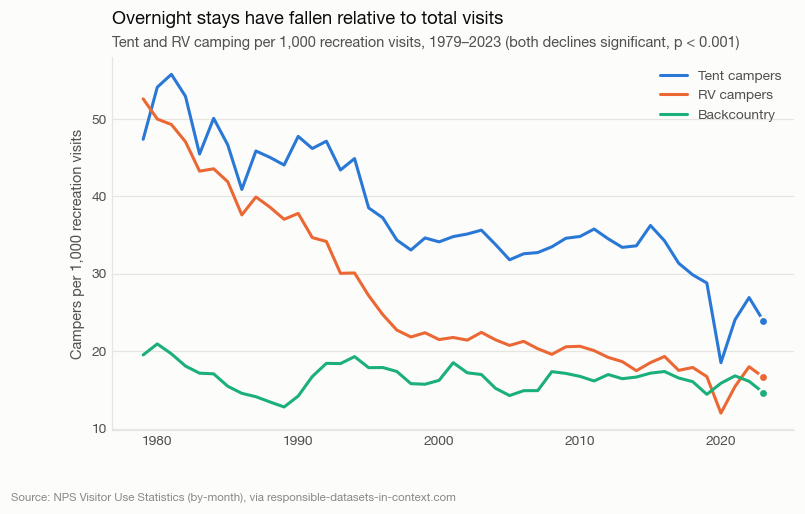

In [12]:
fig, ax = npviz.new_figure(8, 4.4)
series_colors = {"TentCampers": npviz.BLUE, "RVCampers": npviz.ORANGE, "Backcountry": npviz.AQUA}
labels = {"TentCampers": "Tent campers", "RVCampers": "RV campers", "Backcountry": "Backcountry"}
for col, color in series_colors.items():
    ax.plot(per_1000.index, per_1000[col], color=color, lw=2, label=labels[col])
    npviz.end_label(ax, per_1000.index[-1], per_1000[col].iloc[-1], "", color=color, dx=0)
ax.set_ylabel("Campers per 1,000 recreation visits")
npviz.title(ax, "Overnight stays have fallen relative to total visits",
            "Tent and RV camping per 1,000 recreation visits, 1979–2023 (both declines significant, p < 0.001)")
ax.legend(loc="upper right")
npviz.source_note(fig)
npviz.save(fig, "03_overnight_rate_trend")
plt.show()


Tent camping per 1,000 visits has fallen roughly 14% per decade and RV
camping roughly 24% per decade (both *p* < 0.001); backcountry camping shows
no significant trend. In raw counts, tent camper-nights are roughly flat and
backcountry stays have actually *grown* — it's specifically the *rate*
relative to a fast-growing visitor base that has fallen, i.e. camping
capacity/behavior hasn't kept pace with the growth in total visits.

### Is this a mix-shift, or a real behavior change?

Total visits have grown fastest in parks that were never camping-heavy
(e.g. urban-adjacent or drive-through parks). A shift-share decomposition
separates how much of the change in the *national* camping rate comes from
(a) individual parks camping less ("within"), versus (b) visit growth
shifting toward parks that camp less ("between"/mix), comparing 1979–1983
to 2017–2023 (2020–2021 are far enough from the endpoints not to be
determinative, but see the note below).

In [13]:
decomp = npdata.shift_share(df, early=(1979, 1983), late=(2017, 2023),
                            numerator=["TentCampers", "RVCampers"])
decomp.round(3)


rate_early           0.099
rate_late            0.044
total_change        -0.056
within_share         0.995
between_share       -0.233
interaction_share    0.238
dtype: float64

~99% of the drop is attributable to **within-park** change — the same set
of parks that were high-camping in 1979 are, on average, still high-camping
in relative terms, but camping rates have fallen inside almost every park.
The "between-park" (mix) and interaction terms roughly cancel and are small
by comparison. This directly rules out the alternative explanation that
national growth simply happened to concentrate in already-low-camping
parks.

We can see the same within-park pattern directly by tracking a few of the
largest, longest-running parks individually:

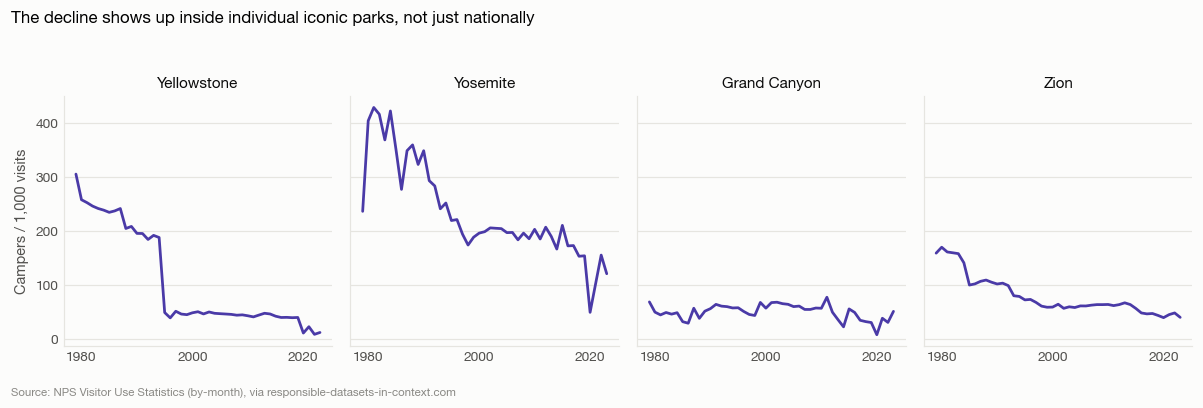

In [14]:
big_parks = ["Yellowstone NP", "Yosemite NP", "Grand Canyon NP", "Zion NP"]
fig, axes = plt.subplots(1, len(big_parks), figsize=(11, 3.2), sharey=True)
for ax, park in zip(axes, big_parks):
    sub = df[df.ParkName == park].groupby("Year")[["RecreationVisits", "TentCampers", "RVCampers"]].sum()
    rate = (sub["TentCampers"] + sub["RVCampers"]) / sub["RecreationVisits"] * 1000
    ax.plot(rate.index, rate.values, color=npviz.VIOLET, lw=1.8)
    ax.set_title(park.replace(" NP", ""), fontsize=10, color=npviz.TEXT_PRIMARY, loc="center")
    ax.set_xticks([1980, 2000, 2020])
    ax.grid(axis="y", color=npviz.GRID, lw=0.8)
axes[0].set_ylabel("Campers / 1,000 visits")
fig.suptitle("The decline shows up inside individual iconic parks, not just nationally",
             fontsize=11, fontweight="bold", x=0.01, ha="left", y=1.05)
npviz.source_note(fig)
npviz.save(fig, "04_within_park_camping")
plt.tight_layout()
plt.show()


## Supporting context <a id='Supporting-context'></a>

Two additional patterns are useful context for the two findings above, but
are not standalone claims: a park-level seasonal typology (helps explain
*why* the national trend isn't universal — see Finding 1's robustness
section), and the 2020 shock (a single event, so treated as texture and a
data-quality note rather than a generalizable trend).

### Every park has its own peak season

In [15]:
recent = df[df.Year.between(2019, 2023)]
park_month = npdata.monthly_matrix(recent, ["ParkName"])
park_month_norm = park_month.div(park_month.sum(axis=1), axis=0)
peak_month = park_month_norm.idxmax(axis=1)
order = peak_month.sort_values(kind="stable").index
mat = park_month_norm.loc[order]

n = len(mat)
desert_n = int((peak_month.loc[order] <= 4).sum())
alpine_n = int((peak_month.loc[order] >= 8).sum())
print(f"{desert_n} winter/spring-peak parks, {alpine_n} summer-peak parks, "
      f"{n - desert_n - alpine_n} peak in the Jul/Aug core")


10 winter/spring-peak parks, 14 summer-peak parks, 39 peak in the Jul/Aug core


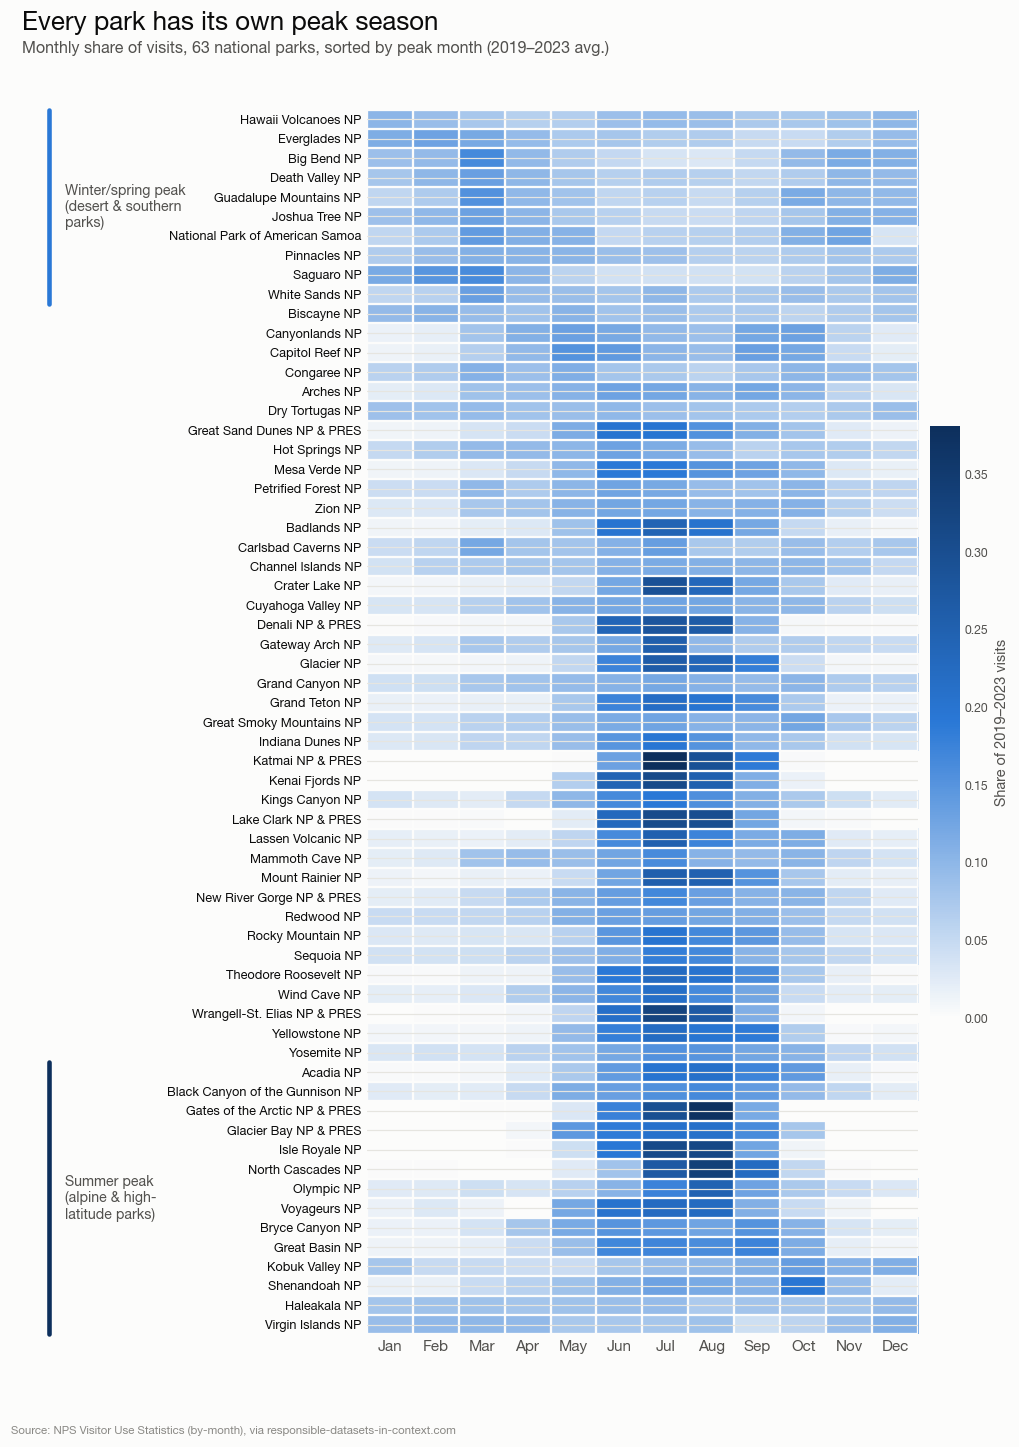

In [16]:
import matplotlib.lines as mlines

fig = plt.figure(figsize=(9.8, 12.8))
fig.patch.set_facecolor(npviz.SURFACE)
ax = fig.add_axes([0.34, 0.045, 0.55, 0.87])
ax.set_facecolor(npviz.SURFACE)

im = ax.imshow(mat.values, aspect="auto", cmap=npviz.SEQUENTIAL, vmin=0, vmax=mat.values.max())
ax.set_xticks(range(12))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"],
                    fontsize=10, color=npviz.TEXT_SECONDARY)
ax.set_yticks(range(n))
ax.set_yticklabels(mat.index, fontsize=8.3, color=npviz.TEXT_PRIMARY)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-0.5, 12, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", color=npviz.SURFACE, linewidth=1.5)
ax.tick_params(which="minor", length=0)

cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.02)
cbar.set_label("Share of 2019–2023 visits", fontsize=9.5, color=npviz.TEXT_SECONDARY)
cbar.ax.tick_params(labelsize=8, labelcolor=npviz.TEXT_SECONDARY)
cbar.outline.set_visible(False)

def row_to_fig_y(row):
    disp = ax.transData.transform((0, row))
    return fig.transFigure.inverted().transform(disp)[1]

top_y, desert_bottom_y = row_to_fig_y(-0.5), row_to_fig_y(desert_n - 0.5)
alpine_top_y, bottom_y = row_to_fig_y(n - alpine_n - 0.5), row_to_fig_y(n - 0.5)
bracket_x = 0.045
fig.add_artist(mlines.Line2D([bracket_x, bracket_x], [desert_bottom_y, top_y], color=npviz.BLUE,
                              lw=3, solid_capstyle="round", transform=fig.transFigure))
fig.text(bracket_x + 0.015, (top_y + desert_bottom_y) / 2, "Winter/spring peak\n(desert & southern\nparks)",
          fontsize=9.3, color=npviz.TEXT_SECONDARY, ha="left", va="center")
fig.add_artist(mlines.Line2D([bracket_x, bracket_x], [bottom_y, alpine_top_y], color=npviz.DARK_BLUE,
                              lw=3, solid_capstyle="round", transform=fig.transFigure))
fig.text(bracket_x + 0.015, (alpine_top_y + bottom_y) / 2, "Summer peak\n(alpine & high-\nlatitude parks)",
          fontsize=9.3, color=npviz.TEXT_SECONDARY, ha="left", va="center")

fig.suptitle("Every park has its own peak season", fontsize=17, fontweight="bold",
             color=npviz.TEXT_PRIMARY, x=0.02, ha="left", y=0.985)
fig.text(0.02, 0.955, "Monthly share of visits, 63 national parks, sorted by peak month (2019–2023 avg.)",
          fontsize=10.5, color=npviz.TEXT_SECONDARY, ha="left")
npviz.source_note(fig)
npviz.save(fig, "05_seasonal_typology_heatmap")
plt.show()


This explains why Finding 1's per-park trend chart has a small cluster of
increasing parks: they are disproportionately the extreme summer-peak
Alaska parks (Katmai, Wrangell–St. Elias, Lake Clark), which have historically
had very short, hard seasons and are seeing that season lengthen slightly as
tourism to them grows — the opposite direction from the desert-park pattern
but consistent with the same broader story of *changing* seasonal windows.

### The 2020 shock hit regions unevenly

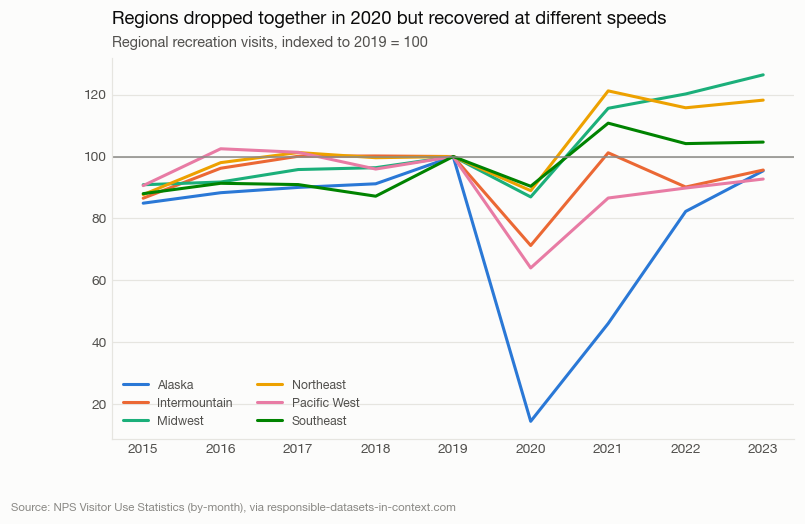

In [17]:
region_year = df.groupby(["Region", "Year"])["RecreationVisits"].sum().unstack("Year")
region_idx = region_year.div(region_year[2019], axis=0) * 100

fig, ax = npviz.new_figure(8, 4.5)
for color, region in zip(npviz.CATEGORICAL, region_idx.index):
    sub = region_idx.loc[region, 2015:2023]
    ax.plot(sub.index, sub.values, lw=2, color=color, label=region)
ax.axhline(100, color=npviz.TEXT_MUTED, lw=1, ls=(0, (1, 0)))
npviz.title(ax, "Regions dropped together in 2020 but recovered at different speeds",
            "Regional recreation visits, indexed to 2019 = 100")
ax.legend(loc="lower left", fontsize=8, ncol=2)
npviz.source_note(fig)
npviz.save(fig, "06_regional_covid_recovery")
plt.show()


**Data-quality note.** The data essay flags known counter outages (e.g.
Carlsbad Caverns' counter broken since 2019) and non-reporting zeros (e.g.
Kobuk Valley, 2014–2015), and that the 2024 annual figures were reportedly
suppressed after release. We restrict this analysis to 2023 and earlier for
that reason. Checking whether the 2020 regional drop is inflated by
non-reporting rather than real closures:

In [18]:
zeros_2020 = df[(df.Year == 2020) & (df.ZeroMonth)]
print(f"{len(zeros_2020)} zero-visit rows in 2020 across {zeros_2020.ParkName.nunique()} parks — "
      f"a small share of the {df[df.Year==2020].shape[0]} park-months that year, "
      "consistent with real (COVID) closures rather than a reporting artifact.")


46 zero-visit rows in 2020 across 26 parks — a small share of the 756 park-months that year, consistent with real (COVID) closures rather than a reporting artifact.


## Limitations and generalizability <a id='Limitations'></a>

- **Measurement, not census.** "Recreation visits" are estimated from
  traffic counters and manual counts, adjusted by park-specific formulas
  that changed over 45 years (per the data essay). A slow methodological
  drift toward more granular counting could itself produce part of a
  "de-seasonalization" signal if peak-month counts were historically
  cruder than shoulder-month counts — we have no way to rule this out from
  the visitation data alone, so we treat the finding as measured-share
  de-seasonalization, not a claim about literal foot traffic.
- **Definitional exclusions.** The data essay notes that "recreation
  visits" exclude commuters, researchers, staff, and Indigenous residents
  of park lands, and that limited accessibility means visitors are not
  representative of the U.S. population. Our findings describe *counted*
  visitation behavior, not visitation in the broadest social sense.
- **Camping rate is a behavior proxy, not a survey.** `TentCampers` /
  `RVCampers` reflect campground *stays*, which are also bounded by fixed
  campsite capacity in popular parks — a flat or declining rate could
  partly reflect a capacity ceiling rather than pure declining demand for
  camping. We cannot separate supply constraints from demand shifts with
  this dataset alone.
- **One shock event.** The 2020 regional-recovery pattern (Supporting
  context) is a single case (one pandemic), not a repeated, generalizable
  pattern — we present it as texture, not as a claim in its own right.
- **Generalizability.** The 45-year, near-universal-panel trends (Findings
  1 and 2) are our strongest basis for expecting the *direction* of these
  patterns to continue into future years, though the *rate* of decline is
  unlikely to be constant (both slow markedly after ~2010 in the raw
  series). We would not extend either finding to park types not
  represented in this list (63 "National Park"-designated units only —
  national monuments, seashores, and historic sites are excluded from this
  file and may behave differently).


## Recommended claim for the write-up <a id='Recommendation'></a>

**Primary claim:** *National park visitation has been shifting away from
its traditional summer/overnight pattern for four decades — the June–August
visit share has fallen ~1.6 points/decade (95% CI 1.2–2.0, p<0.001) and
overnight camping per 1,000 visits has fallen 14–24%/decade (both p<0.001),
with both trends broad-based across individual parks rather than driven by
a handful of outliers or by 2020's disruption.*

This is preferred over the alternative candidates considered during
exploration (a single-park "most visited" fact; the seasonal-typology
descriptive split; the COVID-recovery comparison) because it is (a)
quantified with a confidence interval and significance test rather than a
before/after comparison of two numbers, (b) checked against three
plausible objections (mix-shift, COVID, definition of "summer"/"camping
rate") and survives all three, and (c) tells a coherent story about *how*
visits are changing, which is squarely what the assignment asks for.
